In [3]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# Load dataset
dfr = pd.read_csv("tested.csv")

# EDA (Exploratory Data Analysis)

In [5]:
print(dfr.head())

   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  


In [6]:
print(dfr.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None


# Filling missing values in Age, Fare and Cabin columns 

In [7]:
# Fill missing values
age_median = dfr['Age'].median()
fare_median = dfr['Fare'].median()

# Fill missing values via a single DataFrame-wide fillna
fill_values = {
    'Age': age_median,
    'Fare': fare_median
}
# Only fill Cabin if it exists; otherwise this key is ignored
if 'Cabin' in dfr.columns:
    fill_values['Cabin'] = 'Unknown'

dfr = dfr.fillna(fill_values)

dfr.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Unknown,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,Unknown,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Unknown,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,Unknown,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,Unknown,S


# Cleaning the ambiguous values in the "Name" column (e.g :- Kelly, Mr. James) and creating two seperate columns first_name and last_name

In [8]:
# Cleaning the ambiguous row Name by splitting it into first_name and Last_name

def clean_titanic_test(input_path="tested.csv",
                       output_path="tested_cleaned.csv"):
    # 1. Load
    df = pd.read_csv(input_path)
    print("Cols before cleaning:", df.columns.tolist())

    # 2. Fillna for Age, Fare, (and Cabin if present)
    replacements = {
        'Age': df['Age'].median(),
        'Fare': df['Fare'].median()
    }
    if 'Cabin' in df.columns:
        replacements['Cabin'] = 'Unknown'
    df = df.fillna(replacements)

    # 3. Only split Name if it truly exists
    if 'Name' in df.columns:
        def extract_name_parts(name):
            last, rest = name.split(',', 1)
            title, first = rest.strip().split('.', 1)
            return pd.Series({
                'Last_Name':  last.strip(),
                'Title':      title.strip(),
                'First_Name': first.strip()
            })

        name_df = df['Name'].apply(extract_name_parts)
        df = pd.concat([df, name_df], axis=1)
        df = df.drop(columns=['Name'])
        print("Split Name into Last_Name/Title/First_Name")
    else:
        print("→ No Name column found; skipping name split.")

    # 4. Save
    print("Cols after cleaning:", df.columns.tolist())
    df.to_csv(output_path, index=False)
    print(f"✔ Cleaned data written to {output_path}")

# Run it
clean_titanic_test()

Cols before cleaning: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Split Name into Last_Name/Title/First_Name
Cols after cleaning: ['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Last_Name', 'Title', 'First_Name']
✔ Cleaned data written to tested_cleaned.csv


# Dataset after cleaning

In [9]:
# Cleaned data set

df=pd.read_csv("tested_cleaned.csv")
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Last_Name,Title,First_Name
0,892,0,3,male,34.5,0,0,330911,7.8292,Unknown,Q,Kelly,Mr,James
1,893,1,3,female,47.0,1,0,363272,7.0000,Unknown,S,Wilkes,Mrs,James (Ellen Needs)
2,894,0,2,male,62.0,0,0,240276,9.6875,Unknown,Q,Myles,Mr,Thomas Francis
3,895,0,3,male,27.0,0,0,315154,8.6625,Unknown,S,Wirz,Mr,Albert
4,896,1,3,female,22.0,1,1,3101298,12.2875,Unknown,S,Hirvonen,Mrs,Alexander (Helga E Lindqvist)


In [10]:
# Cleaned dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Cabin        418 non-null    object 
 10  Embarked     418 non-null    object 
 11  Last_Name    418 non-null    object 
 12  Title        418 non-null    object 
 13  First_Name   418 non-null    object 
dtypes: float64(2), int64(5), object(7)
memory usage: 45.8+ KB


In [11]:
# Keep original 'Sex' and 'Embarked' for visualizations
df['Sex_orig'] = df['Sex']
df['Embarked_orig'] = df['Embarked']

# Drop unnecessary columns and handle missing data
df = df[['Survived', 'Pclass', 'Sex', 'Sex_orig', 'Age', 'Fare', 'Embarked', 'Embarked_orig']]
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Embarked_orig'] = df['Embarked_orig'].fillna(df['Embarked_orig'].mode()[0])


# Encode categorical variables
label_sex = LabelEncoder()
label_encoder = LabelEncoder()
df['Sex'] = label_sex.fit_transform(df['Sex'])        # male = 1, female = 0
df['Embarked'] = label_encoder.fit_transform(df['Embarked'])

# Using the Random Forest Classifier for accurate Survival Prediction

In [12]:
# Define features and target
X = df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']]
y = df['Survived']

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84


Confusion Matrix:
 [[50  0]
 [ 0 34]]


# Visualizations

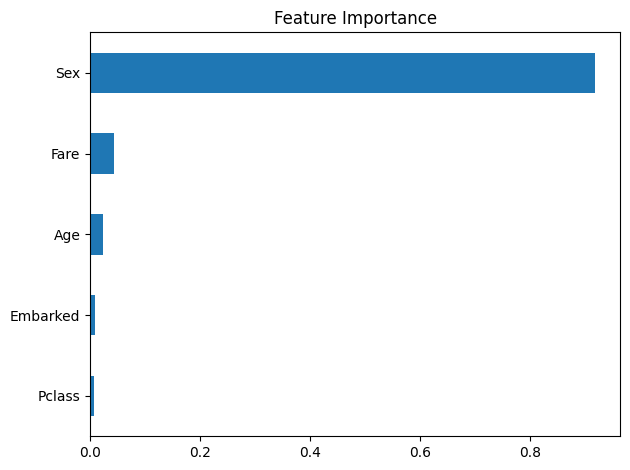

In [13]:
# Feature importance visualization
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.sort_values().plot(kind='barh', title='Feature Importance')
plt.tight_layout()
plt.show()

In [14]:
# Set style
# Set style for seaborn plots
sns.set(style="whitegrid")

# Replace Sex with original labels and create Survived labels
df['Sex_orig'] = df['Sex'].replace({0: 'Female', 1: 'Male'})
df['Survived'] = df['Survived'].replace({0: 'No', 1: 'Yes'})

# 1. Survival count by Sex
sex_counts = df.groupby(['Sex_orig', 'Survived']).size().unstack(fill_value=0)
print("Survival counts by Sex:")
print(sex_counts)

Survival counts by Sex:
Survived   No  Yes
Sex_orig          
Female      0  152
Male      266    0


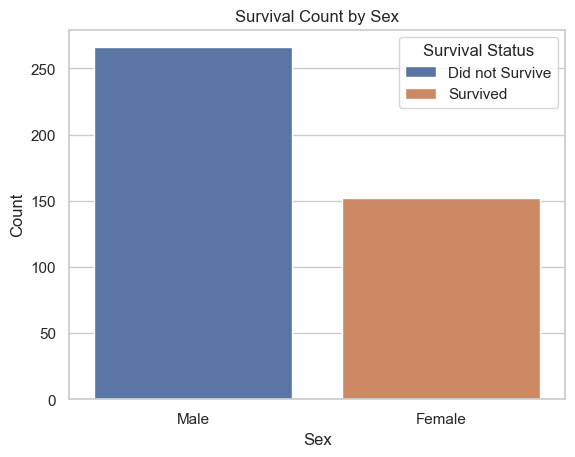

In [15]:
# 2. Side-by-side Count plots like your example

sns.countplot(data=df, x='Sex_orig', hue='Survived')
plt.title('Survival Count by Sex')
plt.legend(['Did not Survive', 'Survived'], title='Survival Status')
plt.xlabel('Sex')
plt.ylabel('Count')

plt.show()

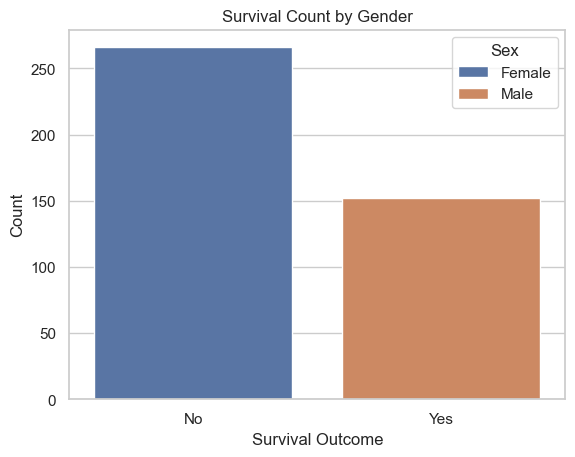

In [16]:
# Plot for Survival count by Survived and Sex

sns.countplot(data=df, x='Survived', hue='Sex_orig')
plt.title('Survival Count by Gender')
plt.legend(['Female', 'Male'], title='Sex')
plt.xlabel('Survival Outcome')
plt.ylabel('Count')

# Display the plots
plt.show()

In [17]:
# 2. Survival count by Pclass
pclass_counts = df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
print("\nSurvival counts by Pclass:")
print(pclass_counts)


Survival counts by Pclass:
Survived   No  Yes
Pclass            
1          57   50
2          63   30
3         146   72


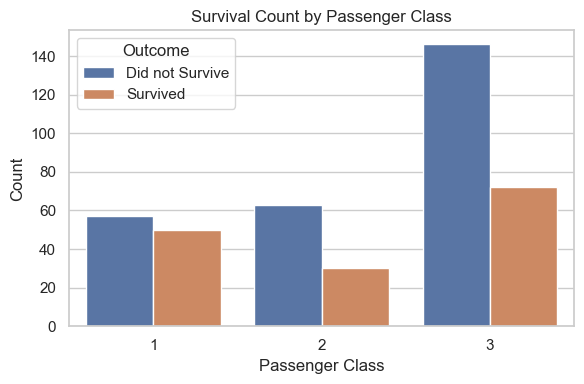

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Survival Count by Passenger Class')
plt.legend(['Did not Survive', 'Survived'], title='Outcome')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

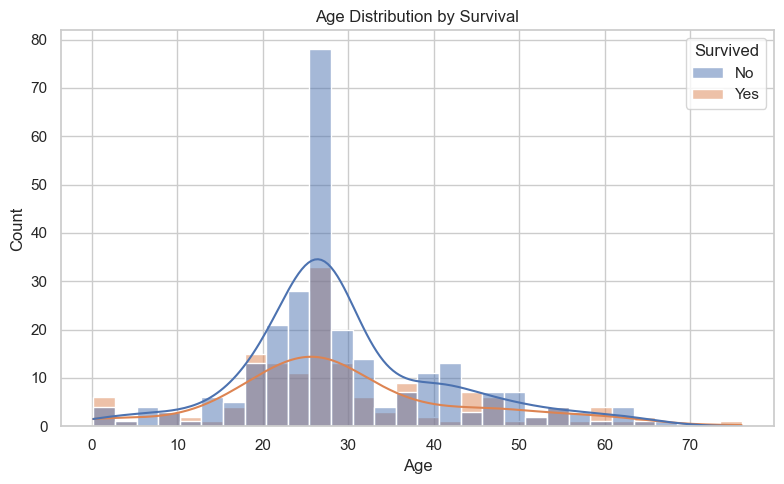

In [19]:
# 3. Age distribution by Survival
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)
plt.title('Age Distribution by Survival')
plt.tight_layout()
plt.show()

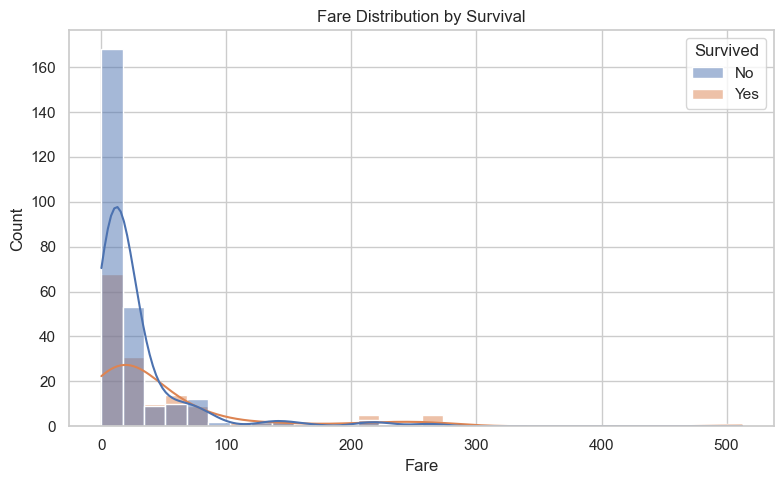

In [20]:
# 4. Fare distribution by Survival
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Fare', hue='Survived', bins=30, kde=True)
plt.title('Fare Distribution by Survival')
plt.tight_layout()
plt.show()

In [21]:
# 5. Survival count by Embarked location
embarked_counts = df.groupby(['Embarked_orig', 'Survived']).size().unstack(fill_value=0)
print("\nSurvival counts by Embarked:")
print(embarked_counts)


Survival counts by Embarked:
Survived        No  Yes
Embarked_orig          
C               62   40
Q               22   24
S              182   88


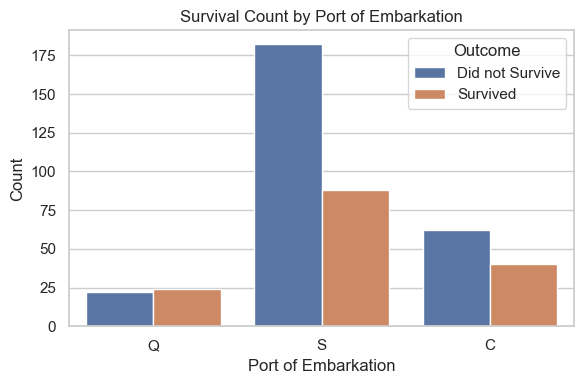

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Embarked_orig', hue='Survived')
plt.title('Survival Count by Port of Embarkation')
plt.legend(['Did not Survive', 'Survived'], title='Outcome')
plt.xlabel('Port of Embarkation')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [23]:
# 6. Survival by Sex and Age Bins
df['AgeBin'] = pd.cut(df['Age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80], labels=["0-10","11-20","21-30","31-40","41-50","51-60","61-70","71-80"])
age_sex_counts = df.groupby(['AgeBin', 'Sex_orig', 'Survived'], observed=True).size().unstack(fill_value=0)
print("\nSurvival counts by Age Group and Sex:")
print(age_sex_counts)


Survival counts by Age Group and Sex:
Survived          No  Yes
AgeBin Sex_orig          
0-10   Female      0   10
       Male       12    0
11-20  Female      0   22
       Male       25    0
21-30  Female      0   70
       Male      147    0
31-40  Female      0   20
       Male       35    0
41-50  Female      0   15
       Male       31    0
51-60  Female      0   11
       Male        9    0
61-70  Female      0    3
       Male        7    0
71-80  Female      0    1


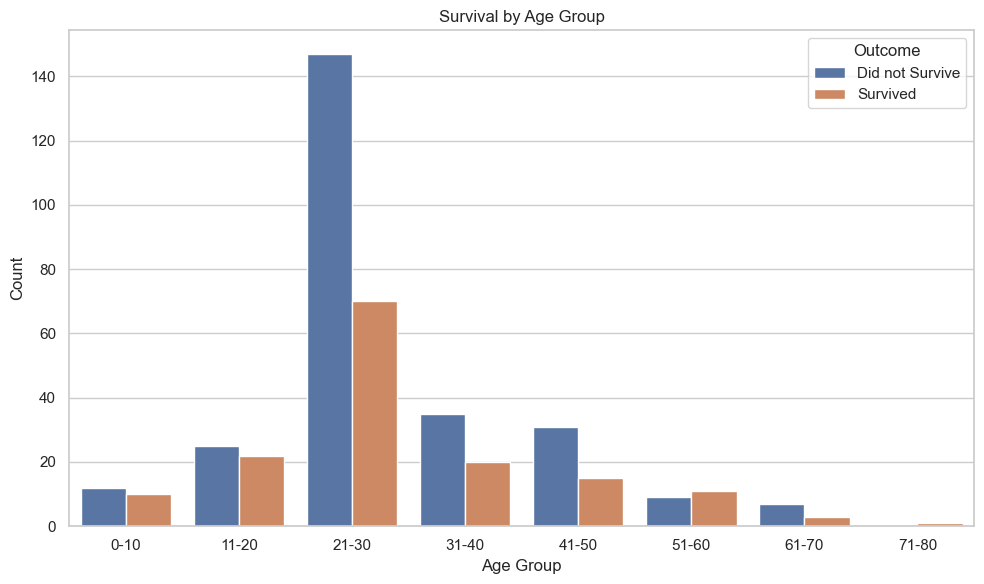

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='AgeBin', hue='Survived')
plt.title('Survival by Age Group')
plt.legend(['Did not Survive', 'Survived'], title='Outcome')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.tight_layout()
plt.show()